#  VAE and GAN
###  **DSBA 6165: AI & Deep Learning**
### Minwoo "Jake" Lee

## Goal

The goal of this lab activity is to learn and practice two generative models, variational autoencoders (VAE) and generative adversarial networks (GAN).

Let us first import the libraries we are going to use. TensorFlow for DL models, matplotlib and seaborn for plotting data/results, numpy and pandas for data handling. This time, to shorten the code, we directly import more keras models and tools.

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.datasets import imdb # IMDB dataset is included in Keras

from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.layers import Embedding, LSTM
from tensorflow.keras.utils import to_categorical          # Converts a class vector (integers) to binary class matrix.
from tensorflow.keras import regularizers

print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import random                        # for generating random numbers
import string

%matplotlib inline

TF version: 2.20.0


This plot function is repeatedly used to show your learning curves, so let us define before starting the rest.

In [36]:
def plot_learning(history):
    tgts = ['loss', 'accuracy']
    vtgts = ['val_loss', 'val_accuracy']

    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
      plt.subplot(1,2, i+1)
      plt.plot(history.history[tgt], label=tgt)
      plt.plot(history.history[val_tgt], label=val_tgt)
      plt.xlabel('Epoch')
      #plt.ylabel(ylab)
      plt.legend()
      plt.title(f"Training and validation {tgt}")

# Variational Autoencoders (VAE)

## Generating images with variational autoencoders

The most popular and successful application of creative AI today is image generation: learning latent visual spaces and sampling from them to create entirely new pictures interpolated from real ones—pictures of imaginary people, imaginary places, imaginary cats and dogs, and so on.

In this section and the next, we’ll review some high-level concepts pertaining to image generation, alongside implementation details relative to the two main techniques in this domain: variational autoencoders (VAEs) and generative adversarial networks (GANs). Note that the techniques I’ll present here aren’t specific to images—you could develop latent spaces of sound, music, or even text, using GANs and VAEs—but in practice, the most interesting results have been obtained with pictures, and that’s what we’ll focus on here.

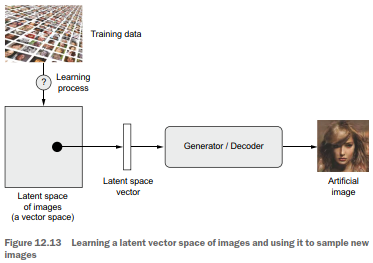

## Sampling from latent spaces of images

The key idea of image generation is to develop a low-dimensional latent space of representations (which, like everything else in deep learning, is a vector space), where any point can be mapped to a “valid” image: an image that looks like the real thing. The module capable of realizing this mapping, taking as input a latent point and outputting an image (a grid of pixels), is called a generator (in the case of GANs) or a decoder (in the case of VAEs). Once such a latent space has been learned, you can sample points from it, and, by mapping them back to image space, generate images that have never been seen before (see figure 12.13). These new images are the in-betweens of the training images.

GANs and VAEs are two different strategies for learning such latent spaces of
image representations, each with its own characteristics. VAEs are great for learning latent spaces that are well structured, where specific directions encode a meaningful axis of variation in the data (see figure 12.14). GANs generate images that can potentially be highly realistic, but the latent space they come from may not have as much structure and continuity.

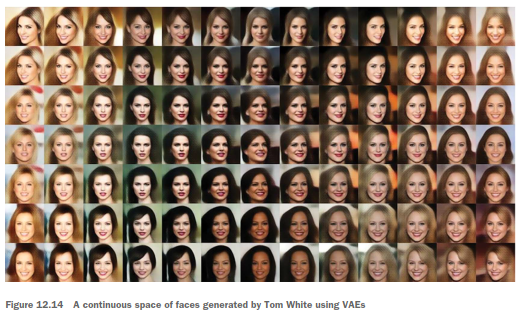

## Concept vectors for image editing

Given a latent space of representations, or an embedding space, certain directions in the space may encode interesting axes of variation in the original data. In a latent space of images of faces, for instance, there may be a smile vector, such that if latent point z is the embedded representation of a certain face, then latent point z + s is the embedded representation of the same face, smiling.

Once you’ve identified such a vector, it then becomes possible to edit images by projecting them into the latent space, moving their representation in a meaningful way, and then decoding them back to image space. There are concept vectors for essentially any independent dimension of variation in image space—in the case of faces, you may discover vectors for adding sunglasses to a face, removing glasses, turning a male face into a female face, and so on. Figure 12.15 is an example of a smile vector, a concept vector discovered by Tom White, from the Victoria University School of Design in New Zealand, using VAEs trained on a dataset of faces of celebrities (the CelebA dataset).

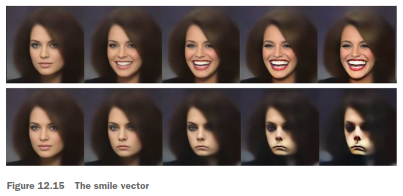

Variational autoencoders

Variational autoencoders, simultaneously discovered by Kingma and Welling in
December 2013 and Rezende, Mohamed, and Wierstra in January 2014 are a kind
of generative model that’s especially appropriate for the task of image editing via concept vectors. They’re a modern take on autoencoders (a type of network that aims to encode an input to a low-dimensional latent space and then decode it back) that mixes ideas from deep learning with Bayesian inference.

A classical image autoencoder takes an image, maps it to a latent vector space via an encoder module, and then decodes it back to an output with the same dimensions as the original image, via a decoder module (see figure 12.16). It’s then trained by using as target data the same images as the input images, meaning the autoencoder learns to reconstruct the original inputs. By imposing various constraints on the code (the output of the encoder), you can get the autoencoder to learn more- or less-interesting latent representations of the data. Most commonly, you’ll constrain the code to be low-dimensional and sparse (mostly zeros), in which case the encoder acts as a way to compress the input data into fewer bits of information.

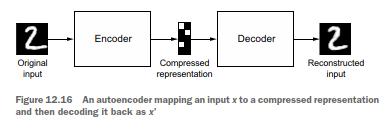

In practice, such classical autoencoders don’t lead to particularly useful or nicely structured latent spaces. They’re not much good at compression, either. For these reasons, they have largely fallen out of fashion. VAEs, however, augment autoencoders with a little bit of statistical magic that forces them to learn continuous, highly structured latent spaces. They have turned out to be a powerful tool for image generation.

A VAE, instead of compressing its input image into a fixed code in the latent
space, turns the image into the parameters of a statistical distribution: a mean and a variance. Essentially, this means we’re assuming the input image has been generated by a statistical process, and that the randomness of this process should be taken into account during encoding and decoding. The VAE then uses the mean and variance parameters to randomly sample one element of the distribution, and decodes that element back to the original input (see figure 12.17). The stochasticity of this process improves robustness and forces the latent space to encode meaningful representations everywhere: every point sampled in the latent space is decoded to a valid output.

In technical terms, here’s how a VAE works:

1.   An encoder module turns the input sample, input_img, into two parameters in
a latent space of representations, z_mean and z_log_variance.
2.   You randomly sample a point z from the latent normal distribution that’s
assumed to generate the input image, via z = z_mean + exp(z_log_variance) *
epsilon, where epsilon is a random tensor of small values.
3.   A decoder module maps this point in the latent space back to the original
input image.

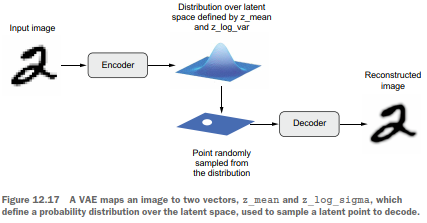

Because epsilon is random, the process ensures that every point that’s close to the latent location where you encoded input_img (z-mean) can be decoded to something similar to input_img, thus forcing the latent space to be continuously meaningful. Any two close points in the latent space will decode to highly similar images. Continuity, combined with the low dimensionality of the latent space, forces every direction in the latent space to encode a meaningful axis of variation of the data, making the latent space very structured and thus highly suitable to manipulation via concept vectors.

The parameters of a VAE are trained via two loss functions: a reconstruction loss that forces the decoded samples to match the initial inputs, and a regularization loss that helps learn well-rounded latent distributions and reduces overfitting to the training data. Schematically, the process looks like this:

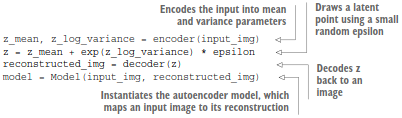

You can then train the model using the reconstruction loss and the regularization loss. For the regularization loss, we typically use an expression (the Kullback–Leibler divergence) meant to nudge the distribution of the encoder output toward a well-rounded normal distribution centered around 0. This provides the encoder with a sensible assumption about the structure of the latent space it’s modeling.  Now let’s see what implementing a VAE looks like in practice!

## Implementing a VAE with Keras

We’re going to be implementing a VAE that can generate MNIST digits. It’s going to
have three parts:

*   An encoder network that turns a real image into a mean and a variance in the
latent space
*   A sampling layer that takes such a mean and variance, and uses them to sample a random point from the latent space
*   A decoder network that turns points from the latent space back into images

The following listing shows the encoder network we’ll use, mapping images to the
parameters of a probability distribution over the latent space. It’s a simple convnet that maps the input image x to two vectors, z_mean and z_log_var. One important detail is that we use strides for downsampling feature maps instead of max pooling. The last time we did this was in the image segmentation example. Recall that, in general, strides are preferable to max pooling for any model that cares about information location—that is to say, where stuff is in the image—and this one does, since it will have to produce an image encoding that can be used to reconstruct a valid image.

### TODO 1
1. Create a variable called `latent_dim` and set the dimension to "2".
2. Create a variable called `encoder_inputs` and define the input shape of the model Using `keras.Input` with shape of `shape=(28,28,1)`
3. Create a variable called `x`, Define a convolutional layer using `layers.Conv2D` with `32` filters, a kernel size of `3x3`, a `ReLU` `activation` function, and a `strides` of `2`. The `padding` parameter is set to "same", which means that the output of the layer will have the same `encoder_inputs` as the input.
4. Create a variable called `x`, Define another convolutional layer using `layers.Conv2D` with `64` filters, a kernel size of `3x3`, a `ReLU` `activation` function, and a `strides` of `2`. The `padding` parameter is set to "same", which means that the output of the layer will have the same `x` as the input.
5. Create a variable called `x`, apply `Flatten()` layer on previous layer `x`.
5. Create a variable called `x`, apply `Dense()` layer with 16 hidden units and ReLU activation on previous layer `x`.
6. Create a variable called `z_mean`, apply `Dense` layer on previous layer `x` with additional arguments `latent_dim` and name the layer as `z_mean`.
7. Create a variable called `z_log_var`, apply `Dense` layer on previous layer `x` with additional arguments `latent_dim` and name the layer as `z_log_var`.
8. Create a variable called `encoder`,creates a Keras Model using `keras.Model` and object that takes `encoder_inputs` as input and outputs a list containing `z_mean` and `z_log_var`, and name the layer as `encoder`.


In [38]:
# TODO
# VAE encoder network

latent_dim = 2



encoder_inputs = keras.Input(shape=(28,28,1))
x = layers.Conv2D(filters = 32, kernel_size = (3,3), activation = "relu", strides=2, padding = "same")(encoder_inputs)
x = layers.Conv2D(filters = 64, kernel_size = (3,3), activation="relu", strides = 2, padding = "same")(x)
x = layers.Flatten()(x)
x = layers.Dense(units = 16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name = "z_mean")(x)
z_log_var = layers.Dense(latent_dim, name = "z_log_var")(x)

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name = "encoder")









Its summary looks like this:

In [7]:
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Next is the code for using z_mean and z_log_var, the parameters of the statistical distribution assumed to have produced input_img, to generate a latent space point z.

### TODO 2
1. Define a new class called `Sampler` that inherits from Keras `layers.Layer` class.
1. Define the call method of the Sampler layer as `call`, it should take following arguments `self` , `z_mean` , `z_log_var`.
1. Create a variable called `batch_size` and calculate the batch size of the input by taking the shape of `z_mean` using `tf.shape` and accessing the first element of the resulting tensor.
1. Create a variable called `z_size` and calculate the size of the latent space z by taking the shape of `z_mean` and accessing the second element of the resulting tensor.
1. Create a variable called `epsilon` and Draw a batch of random normal vectors using `tf.random.normal` and give the argument as `shape` which should be equal to a tuple of `batch_size` and `z_size`.
1. Now return the $$z_{\text{mean}} + \exp\left(\frac{1}{2}z_{\text{log\_var}}\right) * \text{epsilon}$$  
    1. Hint: Use `tf.exp` for exponential


In [9]:
# Latent-space-sampling layer

class Sampler(layers.Layer):

    def call(self, z_mean, z_log_var):
        batch_size = tf.shape(z_mean)[0]
        z_size = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape = (batch_size, z_size))

        return z_mean + tf.exp(z_log_var/2) * epsilon




The following listing shows the decoder implementation. We reshape the vector z to the dimensions of an image and then use a few convolution layers to obtain a final image output that has the same dimensions as the original input_img.

### TODO 3
1. Create a variable called `latent_inputs` and define the input shape of the model Using `keras.Input` with shape of `shape=(latent_dim,)`
2. Create a variable called `x`, Define a Dense layer using `layers.Dense` with tensor shape of `7 * 7 * 64`, having a `ReLU` `activation` function, which means that the output of the layer will have the same `latent_inputs` as the input.
3. Create a variable called `x`, Define a reshape layer using `layers.Reshape` with tensor shape of (7, 7, 64) and apply this on previous layer `x`.
4. Create a variable called `x`,Define a transposed convolutional layer using `layers.Conv2DTranspose` with `64` filters, a kernel size of `3x3`, a `ReLU` `activation` function, and a `strides` of `2`. The `padding` parameter is set to "same", which means that the output of the layer will have the same `x` as the input.
5. Create a variable called `x`,Define a transposed convolutional layer using `layers.Conv2DTranspose` with `32` filters, a kernel size of `3x3`, a `ReLU` `activation` function, and a `strides` of `2`. The `padding` parameter is set to "same", which means that the output of the layer will have the same `x` as the input.
6. Create a variable called `decoder_outputs`, Define a convolutional layer using `layers.Conv2D` with `1` filters, a kernel size of `3x3`, a `sigmoid` `activation` function, The `padding` parameter is set to "same", which means that the output of the layer will have the same `x` as the input.
7. Create a variable called `decoder` create a Keras Model using `keras.Model` taking the `latent_inputs` as input and producing `decoder_outputs` as output and `name` the layer as `decoder`

In [30]:
# TODO
# VAE decoder network, mapping latent space points to images



latent_inputs = keras.Input(shape = (latent_dim,))
x = layers.Dense(units = 7*7*64, activation="relu")(latent_inputs)
x = layers.Reshape(target_shape = (7,7,64))(x)
x = layers.Conv2DTranspose(filters = 64, kernel_size=(3,3), activation = "relu", strides = 2, padding = "same")(x)
x = layers.Conv2DTranspose(filters = 32, kernel_size=(3,3), activation = "relu", strides = 2, padding = "same")(x)
decoder_outputs = layers.Conv2D(filters = 1, kernel_size=(3,3), activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name = "decoder")







Its summary looks like this:

In [33]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Now let’s create the VAE model itself. This is your first example of a model that isn’t doing supervised learning (an autoencoder is an example of self-supervised learning, because it uses its inputs as targets). Whenever you depart from classic supervised learning, it’s common to subclass the Model class and implement a custom train_step() to specify the new training logic. That’s what we’ll do here.

### TODO 4

* 4A Define three instance variables: `encoder`, `decoder`, and `sampler` and assign with respect to each other.
* 4B
    1. Create a varaible called `z_mean`, `z_log_var` in that apply `self.encoder` layer on `data`.
    1. Create a varaible called `z` and then sample from the distribution using the Sampler layer `self.sampler` on `(z_mean, z_log_var)`.
    1. Create a variable called `reconstruction` and apply `decoder` on the previous layer `z`
* 4C
    1. Create a variable called `reconstruction_loss` calculate the mean of the binary cross-entropy `keras.losses.binary_crossentropy` between the input data and the reconstructed output as a tuple `(data, reconstruction)` and `axis` as `(1,2)` ,apply the resulting value to `tf.reduce_mean(tf.reduce_sum`
* 4D
    1. Create a variable called `kl_loss`
$$ kl\_loss = -0.5 \times \left(1 + z\_log\_var - \left(z\_mean\right)^2 - e^{z\_log\_var} \right) $$
        1. Hint: Use `tf$.square` for z_mean and `tf.exp` for exponential
* 4E
    1. Create a variable called `total_loss` with argumnets as sum of the `reconstruction_loss` and `tf.reduce_mean(kl_loss)`
    1. Exit the with statement and create a varaible called `grads`  computes the gradients of the trainable weights with respect to the total loss using the GradientTape using `tape.gradient` on `(total_loss, self.trainable_weights)`
    1. Create an instance called `self.optimizer` using `.apply_gradients` on `zip` of `(grads, self.trainable_weights)`
    1. Now we have to update the values of the total_loss_tracker, reconstruction_loss_tracker, and kl_loss_tracker metrics . Just create instance for the three values as  `self.total_loss_tracker` ,`self.reconstruction_loss_tracker` ,`self.kl_loss_tracker` use `update_state` and update it with respect to each other
    1. Now `return` a dictionary containing the current values of the total_loss, reconstruction_loss, and kl_loss metrics.Update dictionary with additional configuration options specific to this custom layer.Dictionary have the following arguments value of `"total_loss"` set to `self.total_loss_tracker.result()`,` "reconstruction_loss"` set to `self.reconstruction_loss_tracker.result()` , `"kl_loss"` set to `self.kl_loss_tracker.result()`
   

In [43]:
# VAE model with custom train_step()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        #TODO 4A
        self.encoder = encoder
        self.decoder = decoder

        self.sampler = Sampler()

        ######
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")                 # We use these metrics to keep track of the loss averages over each epoch.
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):                                                                  # We list the metrics in the metrics property to enable the model to reset
                                                                                        # them after each epoch (or between multiple calls to fit()/evaluate()).
        return [self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # TODO 4B
            z_mean, z_log_var = self.encoder(data)
            z = self.sampler(z_mean, z_log_var)

            reconstruction = decoder(z)


            # TODO 4C
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction),
                axis = (1,2)
            ))
            # TODO 4D
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))

            # TODO 4E
            total_loss = reconstruction_loss + tf.reduce_mean(kl_loss)


        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

Finally, we’re ready to instantiate and train the model on MNIST digits. Because the loss is taken care of in the custom layer, we don’t specify an external loss at compile time (loss=None), which in turn means we won’t pass target data during training (as you can see, we only pass x_train to the model in fit()).

In [79]:
# Training the VAE
import numpy as np

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)                    # We train on all MNIST digits, so we concatenate
                                                                            # the training and test samples.
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), run_eagerly=True)            # Note that we don’t pass a loss argument in compile(), since the loss is already part of the train_step().
vae.fit(mnist_digits, epochs=30, batch_size=128)                            # Note that we don’t pass targets in fit(), since train_step() doesn’t expect any.

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 66s 120ms/step - kl_loss: 3.0994 - reconstruction_loss: 200.0314 - total_loss: 203.1311
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 131ms/step - kl_loss: 3.7735 - reconstruction_loss: 164.3352 - total_loss: 168.1087
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 72s 132ms/step - kl_loss: 3.7608 - reconstruction_loss: 159.9386 - total_loss: 163.6992
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 59s 107ms/step - kl_loss: 3.8517 - reconstruction_loss: 156.3928 - total_loss: 160.2446
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - kl_loss: 3.9066 - reconstruction_loss: 154.2298 - total_loss: 158.1363
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - kl_loss: 3.9150 - reconstruction_loss: 152.9433 - total_loss: 156.8583
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 110ms/step - kl_loss: 3.9426 - reconstruction_loss: 151.9592 - total_loss: 155.9017
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 60s 110ms/step - kl_loss: 3.9412 - reconstruction_loss: 151.2038

Once the model is trained, we can use the decoder network to turn arbitrary latent space vectors into images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

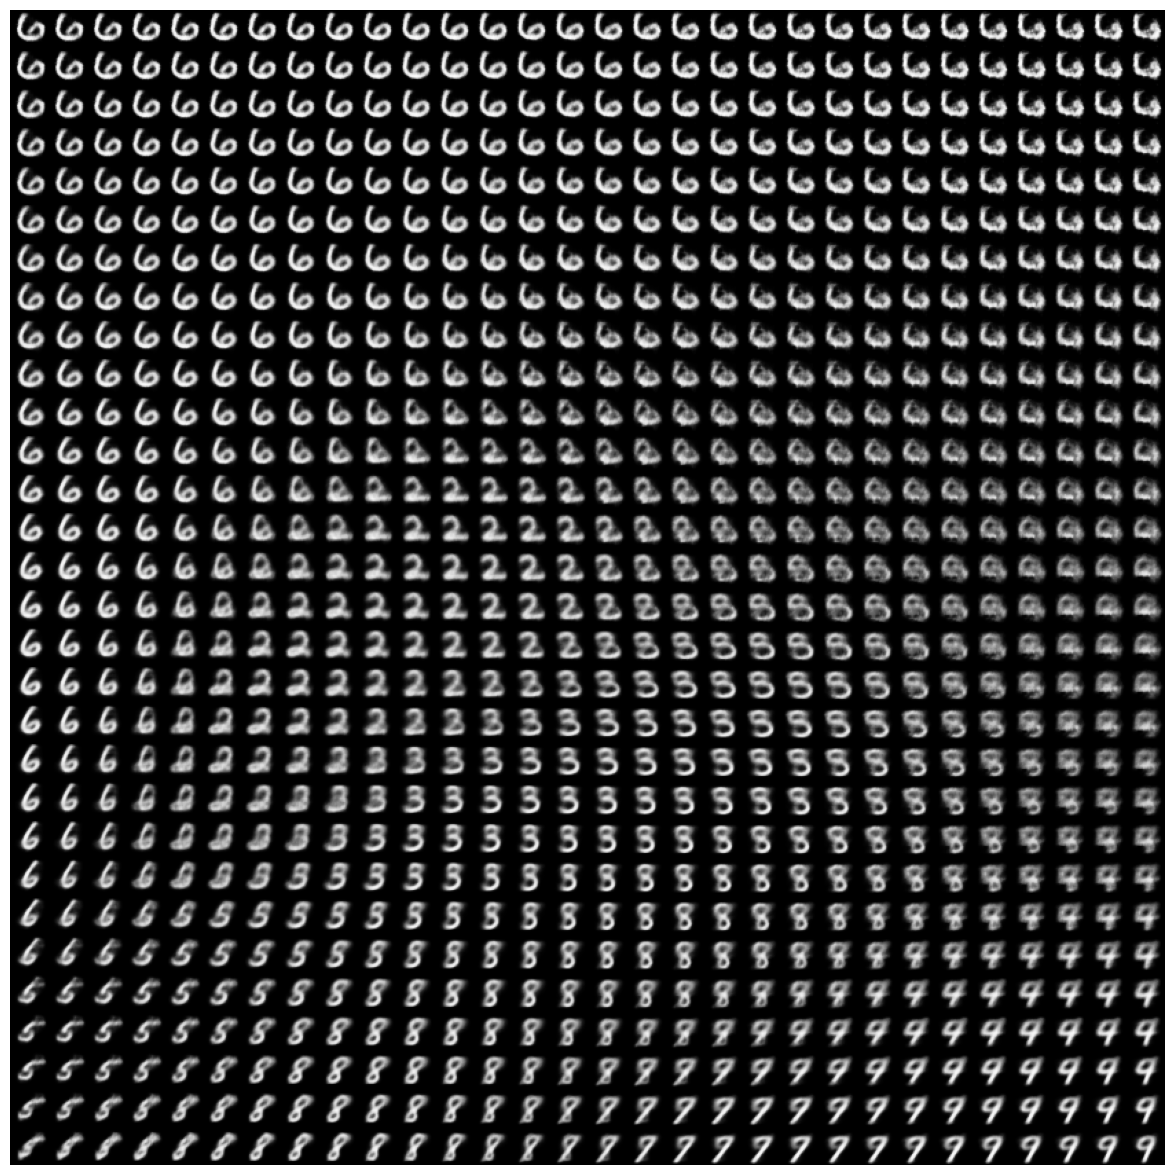

In [80]:
# Sampling a grid of images from the 2D latent space
import numpy as np
import matplotlib.pyplot as plt

n = 30                                                      # We’ll display a grid of 30 × 30  digits (900 digits total).
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-1, 1, n)                              # Sample points linearly on a 2D grid.
grid_y = np.linspace(-1, 1, n)[::-1]

for i, yi in enumerate(grid_y):                             # Iterate over grid locations.
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])                     # For each location, sample a digit and add it to our figure.
        x_decoded = vae.decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.axis("off")
plt.imshow(figure, cmap="Greys_r")

The grid of sampled digits (see figure 12.18) shows a completely continuous distribution of the different digit classes, with one digit morphing into another as you follow a path through latent space. Specific directions in this space have a meaning: for example, there are directions for “five-ness,” “one-ness,” and so on.

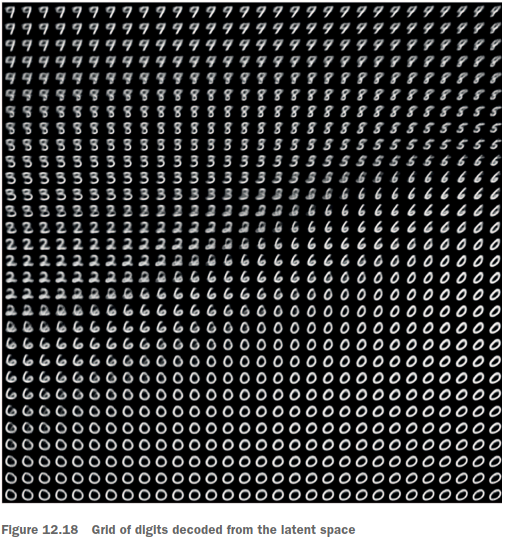

Wrapping up

*   Image generation with deep learning is done by learning latent spaces that capture statistical information about a dataset of images. By sampling and decoding points from the latent space, you can generate never-before-seen images. There are two major tools to do this: VAEs and GANs.
*   VAEs result in highly structured, continuous latent representations. For this reason, they work well for doing all sorts of image editing in latent space: face swapping, turning a frowning face into a smiling face, and so on. They also work nicely for doing latent-space-based animations, such as animating a walk along a cross section of the latent space or showing a starting image slowly morphing into different images in a continuous way.
*   GANs enable the generation of realistic single-frame images but may not induce latent spaces with solid structure and high continuity. Most successful practical applications I have seen with images rely on VAEs, but GANs have enjoyed enduring popularity in the world of academic research. You’ll find out
how they work and how to implement one in the next section.

# Generative Adversarial Networks (GAN)

Generative adversarial networks (GANs), introduced in 2014 by Goodfellow et al., are an alternative to VAEs for learning latent spaces of images. They enable the generation of fairly realistic synthetic images by forcing the generated images to be statistically almost indistinguishable from real ones. An intuitive way to understand GANs is to imagine a forger trying to create a fake
Picasso painting. At first, the forger is pretty bad at the task. He mixes some of his fakes with authentic Picassos and shows them all to an art dealer. The art dealer makes an authenticity assessment for each painting and gives the forger feedback about what makes a Picasso look like a Picasso. The forger goes back to his studio to prepare some new fakes. As time goes on, the forger becomes increasingly competent at imitating the style of Picasso, and the art dealer becomes increasingly expert at spotting fakes.

In the end, they have on their hands some excellent fake Picassos.
That’s what a GAN is: a forger network and an expert network, each being trained
to best the other. As such, a GAN is made of two parts:

*   Generator network—Takes as input a random vector (a random point in the
latent space), and decodes it into a synthetic image
*   Discriminator network (or adversary)—Takes as input an image (real or synthetic), and predicts whether the image came from the training set or was created by the generator network

The generator network is trained to be able to fool the discriminator network, and thus it evolves toward generating increasingly realistic images as training goes on: artificial images that look indistinguishable from real ones, to the extent that it’s impossible for the discriminator network to tell the two apart (see figure 12.19). Meanwhile, the discriminator is constantly adapting to the gradually improving capabilities of the generator, setting a high bar of realism for the generated images. Once training is over, the generator is capable of turning any point in its input space into a believable image. Unlike VAEs, this latent space has fewer explicit guarantees of meaningful structure; in particular, it isn’t continuous.

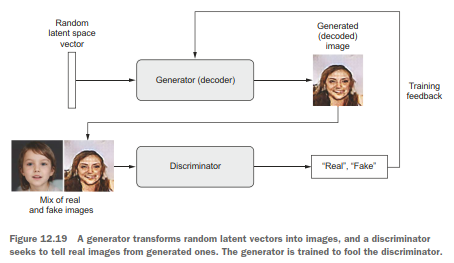

Remarkably, a GAN is a system where the optimization minimum isn’t fixed, unlike in any other training setup you’ve encountered in this book. Normally, gradient descentn consists of rolling down hills in a static loss landscape. But with a GAN, every step taken down the hill changes the entire landscape a little. It’s a dynamic system where the optimization process is seeking not a minimum, but an equilibrium between two forces. For this reason, GANs are notoriously difficult to train—getting a GAN to work requires lots of careful tuning of the model architecture and training parameters.

## A schematic GAN implementation

In this section, we’ll explain how to implement a GAN in Keras in its barest form. GANs are advanced, so diving deeply into the technical details of architectures like that of the StyleGAN2 that generated the images in figure 12.20 would be out of scope for this book. The specific implementation we’ll use in this demonstration is a deep convolutional GAN (DCGAN): a very basic GAN where the generator and discriminator are deep convnets.
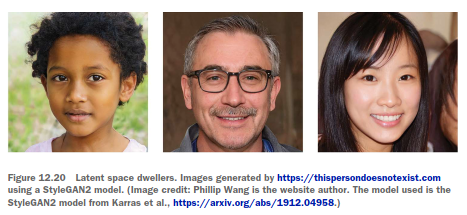

We’ll train our GAN on images from the Large-scale CelebFaces Attributes dataset (known as CelebA), a dataset of 200,000 faces of celebrities (http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) To speed up training, we’ll resize the images to 64 × 64, so we’ll be learning to generate 64 × 64 images of human faces Schematically, the GAN looks like this:

*   A generator network maps vectors of shape (latent_dim,) to images of shape (64, 64, 3).
*   A discriminator network maps images of shape (64, 64, 3) to a binary score estimating the probability that the image is real.
*   A gan network chains the generator and the discriminator together: gan(x) = discriminator(generator(x)). Thus, this gan network maps latent space vectors to the discriminator’s assessment of the realism of these latent vectors as decoded by the generator.
*   We train the discriminator using examples of real and fake images along with “real”/“fake” labels, just as we train any regular image-classification model.
*   To train the generator, we use the gradients of the generator’s weights with regard to the loss of the gan model. This means that at every step, we move the weights of the generator in a direction that makes the discriminator more likely to classify as “real” the images decoded by the generator. In other words, we
train the generator to fool the discriminator.

## A bag of tricks

The process of training GANs and tuning GAN implementations is notoriously difficult. There are a number of known tricks you should keep in mind. Like most things in deep learning, it’s more alchemy than science: these tricks are heuristics, not theory-
backed guidelines. They’re supported by a level of intuitive understanding of the phenomenon at hand, and they’re known to work well empirically, although not necessarily in every context.

Here are a few of the tricks used in the implementation of the GAN generator and discriminator in this section. It isn’t an exhaustive list of GAN-related tips; you’ll find many more across the GAN literature:

*   We use strides instead of pooling for downsampling feature maps in the discriminator, just like we did in our VAE encoder.
*   We sample points from the latent space using a normal distribution (Gaussian distribution), not a uniform distribution.
*   Stochasticity is good for inducing robustness. Because GAN training results in a dynamic equilibrium, GANs are likely to get stuck in all sorts of ways. Introducing randomness during training helps prevent this. We introduce randomness by adding random noise to the labels for the discriminator.
*   Sparse gradients can hinder GAN training. In deep learning, sparsity is often a desirable property, but not in GANs. Two things can induce gradient sparsity: max pooling operations and relu activations. Instead of max pooling, we recommend using strided convolutions for downsampling, and we recommend using a LeakyReLU layer instead of a relu activation. It’s similar to
relu, but it relaxes sparsity constraints by allowing small negative activation values.
*   In generated images, it’s common to see checkerboard artifacts caused by unequal coverage of the pixel space in the generator (see figure 12.21). To fix this, we use a kernel size that’s divisible by the stride size whenever we use a strided Conv2DTranspose or Conv2D in both the generator and the discriminator.

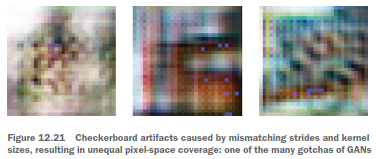

## Getting our hands on the CelebA dataset

You can download the dataset manually from the website: http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html. If you’re using Colab, you can run the following to download the data from Google Drive and uncompress it.

In [45]:
# Install previous version of the library
!pip install -U --no-cache-dir gdown --pre


   ---------------------------------------- 0/3 [tqdm]
   -------------------------- ------------- 2/3 [gdown]
   ---------------------------------------- 3/3 [gdown]



In [48]:
# Getting the CelebA data
import os
import gdown
import zipfile

os.makedirs("celeba_gan", exist_ok=True)


gdown.download(f"https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684", "celeba_gan/data.zip", quiet=False)


with zipfile.ZipFile("celeba_gan/data.zip", 'r') as zip_ref:
    zip_ref.extractall("celeba_gan")

# !mkdir celeba_gan                                                     # Create a working directory.
# !gdown --id 1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684 -O celeba_gan/data.zip  # Download the compressed data using gdown (available by default
                                                                      # in Colab; install it otherwise).
# !unzip -qq celeba_gan/data.zip -d celeba_gan                          # Uncompress the data.

Downloading...
From (original): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684
From (redirected): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684&confirm=t&uuid=738556f0-28bf-4e18-bdb5-0d10d8a0874d
To: c:\Users\brean\Downloads\masters\deep_learning\labs\lab12\celeba_gan\data.zip
100%|██████████| 1.44G/1.44G [00:44<00:00, 32.6MB/s]
 11%|█         | 159M/1.44G [03:24<27:26, 780kB/s] 


Once you’ve got the uncompressed images in a directory, you can use image_data-set_from_directory to turn it into a dataset. Since we just need the images—there are no labels—we’ll specify label_mode=None.

In [52]:
# Creating a dataset from a directory of images
from tensorflow import keras
dataset = keras.utils.image_dataset_from_directory(
   "celeba_gan",
    label_mode=None,        # Only the images will be  returned—no labels.
    image_size=(64, 64),
    batch_size=32)#,
   #  smart_resize=True)      # We will resize the images to 64 × 64 by using a smart
                            # combination of cropping and resizing to preserve aspect
                            # ratio. We don’t want face proportions to get distorted!

Found 202599 files.


Finally, let’s rescale the images to the [0-1] range.

In [53]:
# Rescaling the images
dataset = dataset.map(lambda x: x / 255.)

You can use the following code to display a sample image.

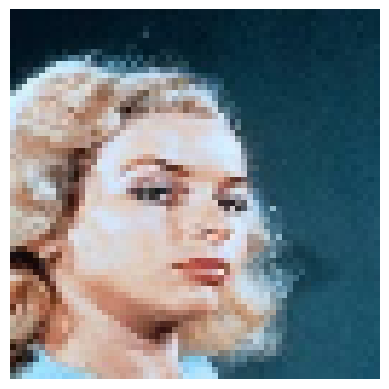

In [55]:
# Displaying the first image
import matplotlib.pyplot as plt
for x in dataset:
    plt.axis("off")
    plt.imshow((x.numpy() * 255).astype("int32")[0])
    break

## The discriminator

First, we’ll develop a discriminator model that takes as input a candidate image (real or synthetic) and classifies it into one of two classes: “generated image” or “real image that comes from the training set.” One of the many issues that commonly arise with GANs is that the generator gets stuck with generated images that look like noise. A possible solution is to use dropout in the discriminator, so that’s what we will do here.

### TODO 5
1. Define the input shape of the discriminator using `keras.Input` with an argument `shape` of `(64, 64, 3)`.
1. The second layer is a convolution layer using `layers.Conv2D` with `64` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Add another convolution layer using `layers.Conv2D` with `128` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a another leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Add one more convolution layer using `layers.Conv2D` with `128` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a another leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Flatten the output of the convolutional layers using `layers.Flatten` no arguments needed.
1. Add a dropout layer to reduce overfitting using `layers.Dropout` and set to `0.2`
1. Finally add a dense layer using `layers.Dense` having `1` filter with an `activation` of `"sigmoid"`


In [50]:
# The GAN discriminator network
from tensorflow.keras import layers

discriminator = keras.Sequential(
    [
        #TODO 5
        keras.Input(shape = (64, 64, 3)),
        layers.Conv2D(filters = 64, kernel_size=(4,4), strides = 2, 
                      padding = "same"),
        layers.LeakyReLU(alpha = 0.2),
        layers.Conv2D(filters = 128, kernel_size=4, strides=2, 
                      padding  = "same"),
        layers.LeakyReLU(alpha = 0.2),
        layers.Conv2D(filters = 128, kernel_size=4, strides=2, 
                      padding  = "same"),
        layers.LeakyReLU(alpha = 0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")

        ######
    ],
    name="discriminator",
)

c:\Users\brean\miniconda3\envs\baseball\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Here’s the discriminator model summary:

In [51]:
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

## The generator

Next, let’s develop a generator model that turns a vector (from the latent space—during training it will be sampled at random) into a candidate image.

### TODO 6
1. Define the input shape of the discriminator using `keras.Input` with an argument `shape` of `(latent_dim,)`.
1. Add a dense layer using `layers.Dense` and having `(8 * 8 * 128)`.
1. using `layers.Reshape` reshapes the output of the fully connected layer into a 3D tensor with shape `(8, 8, 128)`.
1. Add a layer of convolution layer using `layers.Conv2D` with `128` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Add another convolution layer using `layers.Conv2D` with `256` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a another leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Add one more convolution layer using `layers.Conv2D` with `512` filters, a `kernel_size` of `4`,and a `strides` of `2`. The `padding` parameter is set to `"same"`.
1. Add a another leaky ReLU activation function using `layers.LeakyReLU` with a slope(`alpha`) of 0.2.
1. Finally add a convolution layer using `layers.Conv2D` having `3` , a `kernel_size` of `5`,The `padding` parameter is set to `"same"` with an `activation` of `"sigmoid"`


In [74]:
# GAN generator network
latent_dim = 128                                                                   # The latent space will be made of 128-
                                                                                   # dimensional vectors.

generator = keras.Sequential(
    [
        #TODO 6
        keras.Input(shape = (latent_dim,)),
        layers.Dense(8*8*128),
        layers.Reshape((8,8,128)),
        layers.Conv2DTranspose(filters=128, kernel_size=(4,4), strides=2, 
                      padding="same"),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(filters=256, kernel_size=(4,4), strides=2, 
                      padding="same"),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(filters=512, kernel_size=(4,4), strides=2, 
                      padding="same"),
        layers.LeakyReLU(0.2),
        layers.Conv2D(filters=3, kernel_size=(5,5), 
                      padding="same", activation="sigmoid")

        ######
    ],
    name="generator",
)

This is the generator model summary:

In [75]:
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_17 (Reshape)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_31             │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_30 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_32             │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_31 (LeakyReLU)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_32 (LeakyReLU)      │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

## The adversarial network

Finally, we’ll set up the GAN, which chains the generator and the discriminator. When trained, this model will move the generator in a direction that improves its ability to fool the discriminator. This model turns latent-space points into a classification decision—“fake” or “real”—and it’s meant to be trained with labels that are always “these are real images.” So training gan will update the weights of generator in a way that makes discriminator more likely to predict “real” when looking at fake images.

To recapitulate, this is what the training loop looks like schematically. For each epoch, you do the following:
1. Draw random points in the latent space (random noise).
2. Generate images with generator using this random noise.
3. Mix the generated images with real ones.
4. Train discriminator using these mixed images, with corresponding targets: either “real” (for the real images) or “fake” (for the generated images).
5. Draw new random points in the latent space.
6. Train generator using these random vectors, with targets that all say “these are real images.” This updates the weights of the generator to move them toward getting the discriminator to predict “these are real images” for generated images: this trains the generator to fool the discriminator.

Let’s implement it. Like in our VAE example, we’ll use a Model subclass with a custom train_step(). Note that we’ll use two optimizers (one for the generator and one for the discriminator), so we will also override compile() to allow for passing two optimizers.

### TODO 7
* 7A. Define three instance variables: `discriminator`, `generator`, and `latent_dim` and assign with respect to each other.
* 7B  
    1. Create a variable called `generated_images` which equal to `self.generator` and give an argument `random_latent_vectors`
* 7C
    1. Create a new varaible called `predictions` which equal to `self.discriminator` and give an argument `combined_images`
    1. Create another variable `d_loss` which is equal to `self.loss_fn` with two arguments `labels`, `predictions`
* 7D
    1. Create a new varaible  called `predictions` which is equal to `self.discriminator(
                self.generator(random_latent_vectors))`
    1. Create a new varaible  called `g_loss` which is equal to `self.loss_fn` with two arguments `misleading_labels`, `predictions`.
   
   

In [76]:
# The GAN Model
import tensorflow as tf
class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        # TODO 7A
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim


        #######
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")                      # Sets up metrics to track the two
                                                                                    # losses over each training epoch
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(                                   # Samples random points in the latent space
            shape=(batch_size, self.latent_dim))
        # TODO 7B
        generated_images = self.generator(random_latent_vectors)

        ###
        combined_images = tf.concat([generated_images, real_images], axis=0)        # Combines them with real images
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))],                  # Assembles labels, discriminating real from fake images
            axis=0
        )
        labels += 0.05 * tf.random.uniform(tf.shape(labels))                        # Adds random noise to the labels—an important trick!

        with tf.GradientTape() as tape:
            # TODO 7C
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)

            ######
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))                                    # Samples random points in the latent space

        misleading_labels = tf.zeros((batch_size, 1))                               # Assembles labels that say “these are all real
                                                                                    # images” (it’s a lie!)

        with tf.GradientTape() as tape:                                             # Trains the generator
            # TODO 7D
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)


            #####
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result()}

Before we start training, let’s also set up a callback to monitor our results: it will use the generator to create and save a number of fake images at the end of each epoch.

In [77]:
# A callback that samples generated images during training
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = keras.utils.array_to_img(generated_images[i])
            img.save(f"generated_img_{epoch:03d}_{i}.png")

Finally, we can start training.

In [81]:
# Compiling and training the GAN
epochs = 1                                                                          # You’ll start getting interesting results after epoch 20.

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
    dataset, epochs=epochs, callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)

6332/6332 ━━━━━━━━━━━━━━━━━━━━ 12762s 2s/step - d_loss: 0.6106 - g_loss: 1.1885


When training, you may see the adversarial loss begin to increase considerably, while the discriminative loss tends to zero—the discriminator may end up dominating the generator. If that’s the case, try reducing the discriminator learning rate, and increase
the dropout rate of the discriminator.

Figure 12.22 shows what our GAN is capable of generating after 30 epochs of training.

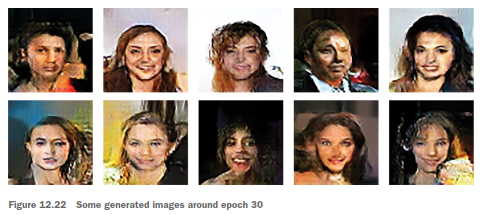

# Wrapping up

*   A GAN consists of a generator network coupled with a discriminator network.The discriminator is trained to differentiate between the output of the generator and real images from a training dataset, and the generator is trained to fool the discriminator. Remarkably, the generator never sees images from the training
set directly; the information it has about the data comes from the discriminator.

*   GANs are difficult to train, because training a GAN is a dynamic process rather than a simple gradient descent process with a fixed loss landscape. Getting a GAN to train correctly requires using a number of heuristic tricks, as well as extensive tuning.
*   GANs can potentially produce highly realistic images. But unlike VAEs, the latent space they learn doesn’t have a neat continuous structure and thus may not be suited for certain practical applications, such as image editing via latent-space concept vectors.

These few techniques cover only the basics of this fast-expanding field. There’s a lot more to discover out there—generative deep learning is deserving of an entire book of its own.